# Backtester

Evaluates betting strategies on real NBA game data. Requires US VPN for database access.

**Pipeline:** Load data → Run strategy → Validate → Metrics → Graphs

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cuic_quant.backtest import (
    load_backtest_data,
    backtest,
    always_bet_home,
    kelly_bet_home_demo,
    validate_backtest_results,
    display_extended_metrics,
    plot_performance,
)

## Load Data
Connects to Railway PostgreSQL. Requires US VPN.

In [ ]:
# Loads real NBA games from Railway PostgreSQL database.
# Requires US VPN connection (database is IP-restricted).
data = load_backtest_data()
print(f"Games loaded: {len(data)}")
data.head()

## Strategy

Replace `strategy` below with your own function. Must return a dict with `action`, `confidence`, and `size`.



- **action**: `BUY_HOME`, `BUY_AWAY`, or `SKIP`
- **confidence**: Your estimated win probability (0-1). Used for Kelly sizing and calibration metrics.
- **size**: Dollar amount to bet (ignored when using Kelly sizing).

In [4]:
strategy = kelly_bet_home_demo

## Run Backtest

Tweak these parameters:
- **`initial_bankroll`**: Starting capital (default 0,000)
- **`position_sizing`**: `None` for flat bets (uses strategy's `size`), `"kelly"` for Kelly Criterion sizing
- **`kelly_fraction`**: 0.25 = quarter-Kelly (conservative), 0.5 = half-Kelly (moderate), 1.0 = full Kelly (aggressive)
- **`cost_pct`**: Percentage cost on winning trades (e.g. 0.05 for 5% vig)
- **`cost_flat`**: Flat fee per trade in dollars

In [5]:
results = backtest(data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)
print(f"Total trades: {len(results)}")
results

Total trades: 870


,timestamp,game,action,bet_size,odds,outcome,pnl,cumulative_pnl,bankroll,confidence,closing_odds
0,2024-10-23 23:00:00+00:00,DET vs IND,BUY_HOME,198.10,2.7100,LOSS,-198.10,-198.10,9801.90,0.419004,1.8091
1,2024-10-23 23:30:00+00:00,ATL vs BKN,BUY_HOME,511.98,1.3146,WIN,161.07,-37.03,9962.97,0.810688,1.0296
2,2024-10-23 23:30:00+00:00,MIA vs ORL,BUY_HOME,284.32,1.7794,LOSS,-284.32,-321.35,9678.65,0.611987,34.0000
3,2024-10-23 23:30:00+00:00,PHI vs MIL,BUY_HOME,286.85,1.7294,LOSS,-286.85,-608.20,9391.80,0.628235,35.0000
4,2024-10-23 23:30:00+00:00,TOR vs CLE,BUY_HOME,184.21,2.7570,LOSS,-184.21,-792.41,9207.59,0.412713,34.0000
...,...,...,...,...,...,...,...,...,...,...,...
865,2026-02-12 01:10:00+00:00,MIN vs POR,BUY_HOME,50.55,1.3676,WIN,18.58,-8894.50,1105.50,0.781208,1.0089
866,2026-02-12 01:10:00+00:00,NOP vs MIA,BUY_HOME,31.16,1.7968,LOSS,-31.16,-8925.66,1074.34,0.606545,5.0930
867,2026-02-12 02:10:00+00:00,DEN vs MEM,BUY_HOME,106.88,1.1437,WIN,15.36,-8910.30,1089.70,0.924355,1.0143
868,2026-02-12 02:10:00+00:00,UTA vs SAC,BUY_HOME,46.64,1.4125,WIN,19.24,-8891.06,1108.94,0.757965,1.0304


## Summary Statistics

In [6]:
if len(results) > 0:
    wins = (results["outcome"] == "WIN").sum()
    losses = (results["outcome"] == "LOSS").sum()
    win_rate = wins / len(results)
    final_pnl = results["cumulative_pnl"].iloc[-1]
    final_bankroll = results["bankroll"].iloc[-1]

    print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
    print(f"Total P&L:       ${final_pnl:,.2f}")
    print(f"Final Bankroll:  ${final_bankroll:,.2f}")
    print(f"ROI:             {final_pnl / 10000:.1%}")
else:
    print("No trades executed.")

Win Rate:        55.1% (479W / 391L)
Total P&L:       $-8,913.04
Final Bankroll:  $1,086.96
ROI:             -89.1%


## Validate Results
12 checks: schema correctness, PnL math, and data leakage detection. Must pass before trusting any results.

In [7]:
report = validate_backtest_results(results, data)

if report["passed"]:
    print(f"PASSED: {report['checks_passed']}/{report['checks_run']} checks passed")
else:
    print(f"FAILED: {report['checks_passed']}/{report['checks_run']} checks passed")
    for f in report["failures"]:
        print(f"  - {f}")

PASSED: 12/12 checks passed


## Performance Metrics
Sharpe, Sortino, drawdown, profit factor, streaks, and more.

In [8]:
display_extended_metrics(results)

       EXTENDED PERFORMANCE METRICS
  Sharpe Ratio:             -1.833
  Sortino Ratio:            -2.274
  Max Drawdown:             89.4%
  Profit Factor:             0.859
  Average Win:          $   113.69
  Average Loss:         $  -162.08
  Win/Loss Ratio:            0.701
  Expected Value/Bet:   $   -10.24
  Longest Win Streak:            8
  Longest Loss Streak:           7
  Best Trade:           $   461.83
  Worst Trade:          $  -866.63


## Performance Graphs

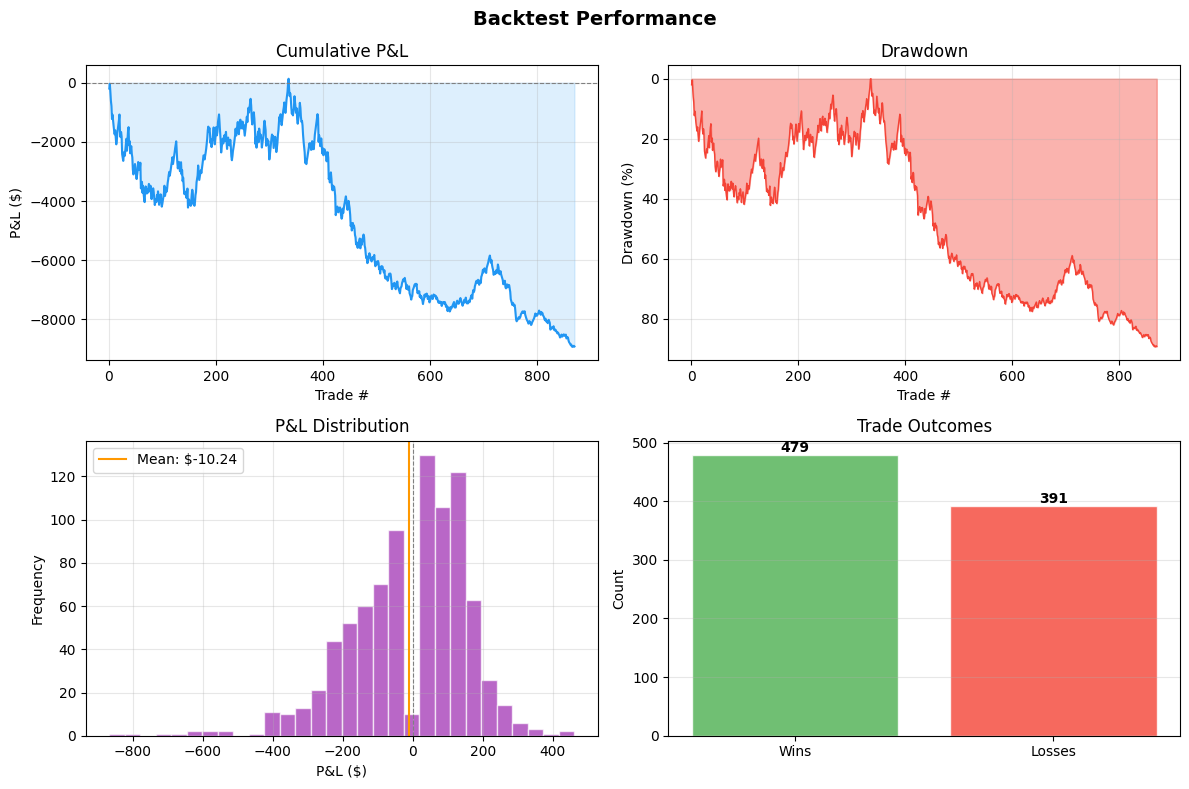

In [9]:
plot_performance(results)

## Train/Test Split

Splits data chronologically: first 70% for developing your strategy, last 30% for evaluation.
Never tune parameters on the test set. If both splits lose money, the strategy has no edge.

Tweak: Change `0.7` in `int(len(data) * 0.7)` to adjust the split ratio.

In [ ]:
# --- Train/Test Split Demonstration ---
# Split data chronologically: first 70% for training, last 30% for testing
split_idx = int(len(data) * 0.7)
train_data = data.iloc[:split_idx].copy()
test_data = data.iloc[split_idx:].copy()

print(f"Total games:  {len(data)}")
print(f"Train set:    {len(train_data)} games ({train_data['timestamp'].iloc[0].date()} to {train_data['timestamp'].iloc[-1].date()})")
print(f"Test set:     {len(test_data)} games ({test_data['timestamp'].iloc[0].date()} to {test_data['timestamp'].iloc[-1].date()})")
print()

# Run backtest on TRAIN data (in-sample)
train_results = backtest(train_data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)
# Run backtest on TEST data (out-of-sample)
test_results = backtest(test_data, strategy, initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25)

from cuic_quant.metrics import calculate_all_metrics

def quick_summary(results_df, label):
    """Print key metrics for a results DataFrame."""
    if len(results_df) == 0:
        print(f"  {label}: No trades executed.")
        return {}
    m = calculate_all_metrics(results_df)
    wins = (results_df["outcome"] == "WIN").sum()
    n = len(results_df)
    pnl = results_df["cumulative_pnl"].iloc[-1]
    print(f"  {label}:")
    print(f"    Trades:       {n}")
    print(f"    Win Rate:     {wins/n:.1%} ({wins}W / {n - wins}L)")
    print(f"    Total PnL:    ${pnl:,.0f}")
    print(f"    Sharpe Ratio: {m.get('sharpe_ratio', 0):.2f}")
    print(f"    Max Drawdown: {-m.get('max_drawdown', 0):.1%}")
    return m

print("=" * 50)
print("  IN-SAMPLE vs OUT-OF-SAMPLE COMPARISON")
print("=" * 50)
train_m = quick_summary(train_results, "Train (in-sample)")
print()
test_m = quick_summary(test_results, "Test (out-of-sample)")

# Verdict
if train_m and test_m:
    train_pnl = train_results["cumulative_pnl"].iloc[-1]
    test_pnl = test_results["cumulative_pnl"].iloc[-1]
    print()
    if train_pnl > 0 and test_pnl < 0:
        print("  -> LIKELY OVERFIT: Profitable in-sample but negative out-of-sample.")
    elif train_pnl < 0 and test_pnl < 0:
        print("  -> No edge detected in either split — strategy is unprofitable.")
    elif abs(train_m.get("sharpe_ratio", 0) - test_m.get("sharpe_ratio", 0)) < 1.0:
        print("  -> Performance consistent across splits — no obvious overfitting.")
    else:
        print("  -> Significant degradation out-of-sample — possible overfitting.")

## Walk-Forward Analysis

Slides a train/test window across the data — trains on each window, tests on the next. Better than a single split.

Tweak:
- **`n_splits`**: Number of folds (more = smaller test windows but more evaluations)
- **`train_ratio`**: Fraction of each fold used for training

In [11]:
from cuic_quant.backtest.walk_forward import walk_forward_backtest, walk_forward_report

wf_results = walk_forward_backtest(
    data, strategy,
    n_splits=3, train_ratio=0.7,
    initial_bankroll=10000.0, position_sizing="kelly", kelly_fraction=0.25,
)
print(walk_forward_report(wf_results))

           WALK-FORWARD ANALYSIS REPORT

  Aggregated Out-of-Sample Metrics
  ----------------------------------------
  Total Trades:           580
  Total PnL:       $ -12869.18
  Win Rate:            52.93%
  Sharpe Ratio:       -4.7614
  Sortino Ratio:      -5.8203
  Max Drawdown:       124.59%
  Profit Factor:       0.7992

  Per-Fold Breakdown
  ----------------------------------------
  Fold 1: train=290 rows, test=290 rows | OOS trades=290, PnL=$-6548.16, WR=53.4%
  Fold 2: train=580 rows, test=291 rows | OOS trades=290, PnL=$-6321.02, WR=52.4%

  In-Sample vs Out-of-Sample Comparison
  ----------------------------------------
  Fold 1: IS PnL=$-1440.98  OOS PnL=$-6548.16  |  IS Sharpe=-0.061  OOS Sharpe=-4.935
  Fold 2: IS PnL=$-7045.55  OOS PnL=$-6321.02  |  IS Sharpe=-1.266  OOS Sharpe=-4.582



## Strategy Comparison
Add your strategies to the dict below to compare them side-by-side.

In [12]:
from cuic_quant.backtest.comparison import compare_strategies, display_comparison

comparison = compare_strategies(
    data,
    {"Kelly Home": kelly_bet_home_demo, "Always Home": always_bet_home},
    initial_bankroll=10000.0,
)
display_comparison(comparison)

              STRATEGY COMPARISON
               total_trades   win_rate  total_pnl  sharpe_ratio  sortino_ratio  max_drawdown  profit_factor  total_wagered  yield_on_turnover  return_on_capital  yield_per_bet   avg_odds  calmar_ratio  bet_frequency  periods_per_year  kelly_growth_rate        clv  brier_score   log_loss
strategy_name                                                                                                                                                                                                                                                                                  
Kelly Home              871     0.5511 -3299.2800       -0.8669        -1.3630        0.4082         0.9156     87100.0000            -0.0379            -0.3299        -0.0379     2.1591       -0.6200         1.8271          667.3451            -0.0005     0.0580       0.2252     0.6431
Always Home             871     0.5511 -3299.2800       -0.8669        -1.3630        0.4082         0

## Statistical Significance
Tests whether results are real or could have happened by chance. P-value < 0.01 = statistically significant.

In [13]:
from cuic_quant.backtest.statistics import significance_report, overfitting_report
from cuic_quant.metrics import calculate_all_metrics
from scipy.stats import skew, kurtosis as kurt

sig = significance_report(results)
print(f"P-value: {sig['p_value']:.4f}")
print(f"Significant at 5%: {sig['is_significant']}")
print(f"Sample size assessment: {sig['sample_size_assessment']}")
print(f"Minimum sample size needed: {sig['min_sample_needed']}")
print()

# Build strategy result dict for overfitting_report
metrics = calculate_all_metrics(results)
pnl = results["pnl"].values
strategy_result = {
    "name": "Kelly Home",
    "sharpe": metrics.get("sharpe_ratio", 0.0),
    "p_value": sig["p_value"],
    "n_trades": len(results),
    "skewness": float(skew(pnl)) if len(pnl) > 2 else 0.0,
    "kurtosis": float(kurt(pnl, fisher=False)) if len(pnl) > 2 else 3.0,
}

ovf = overfitting_report([strategy_result])
print(f"Deflated Sharpe p-value: {ovf['deflated_sharpe_pvalues'][0]:.4f}")

P-value: 0.9768
Significant at 5%: False
Sample size assessment: INSUFFICIENT: 870 trades < 1001 needed (for 5% edge detection)
Minimum sample size needed: 1001

Deflated Sharpe p-value: 0.0000
